<a href="https://colab.research.google.com/github/adithya-ashoks/deep-learning-practice/blob/main/droput_layers_in_ANN_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow  as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

generate data

In [ ]:
x_train = np.linspace(-1,1,20)

In [ ]:
y_train = np.array([
    -0.6561, -0.3099, -0.59035, -0.50855, -0.285,
    -0.2443, -0.02445,  0.00135, -0.2006,  0.07475,
    -0.1422,  0.06515,  0.15265,  0.3521,  0.28415,
     0.5524,  0.23115,  0.20835,  0.4211,  0.60485
])

In [ ]:
x_test = np.linspace(-1,1,20)

In [ ]:
y_test = np.array([
    -0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
    -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
     0.23415,  0.46575,  0.07955,  0.1973  , 0.0719 ,
     0.3639 ,  0.5536 ,  0.3365 ,  0.50705,  0.33435
])

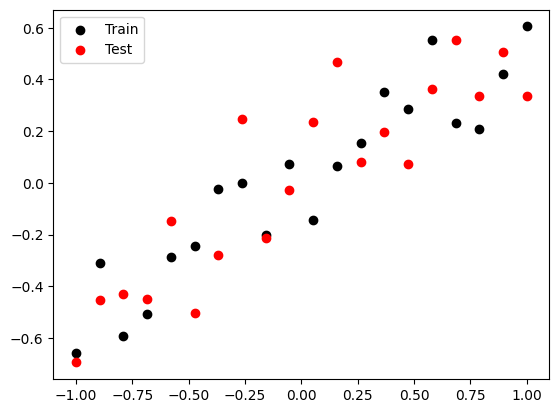

In [ ]:
plt.scatter(x_train,y_train, c= 'black', label = 'Train')
plt.scatter(x_test,y_test,c ='red', label = 'Test')
plt.legend()
plt.show()

Regression model


In [ ]:
model = Sequential()
model.add(Dense(128, input_dim = 1, activation = 'relu'))
model.add(Dense(128, activation = 'relu'))
model.add(Dense(1, activation = 'linear'))

adam = Adam(learning_rate = 0.01)
model.compile(loss = 'mse', optimizer = adam, metrics = ['mse'])
history = model.fit(x_train, y_train, epochs =500, validation_data = (x_test, y_test))

Epoch 1/500


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1348 - mse: 0.1348 - val_loss: 0.0286 - val_mse: 0.0286
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0180 - mse: 0.0180 - val_loss: 0.0575 - val_mse: 0.0575
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0459 - mse: 0.0459 - val_loss: 0.0370 - val_mse: 0.0370
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0245 - mse: 0.0245 - val_loss: 0.0313 - val_mse: 0.0313
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0184 - mse: 0.0184 - val_loss: 0.0411 - val_mse: 0.0411
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0278 - mse: 0.0278 - val_loss: 0.0402 - val_mse: 0.0402
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0270 - mse: 0.0270 - val_loss: 0.0327 - val_mse: 0.0327
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0199 - mse: 0.0199 - val_loss: 0.0290 - val_mse: 0.0290
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0164 - mse: 0.0164 - val_

In [ ]:
# evaluate the model
train_mse = model.evaluate(x_train, y_train, verbose = 0)
test_mse = model.evaluate(x_test, y_test, verbose = 0)
print("train : {},\ntest : {}".format(train_mse,test_mse))


train : [0.0034849296789616346, 0.0034849296789616346],
test : [0.04548180103302002, 0.04548180103302002]


In [ ]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


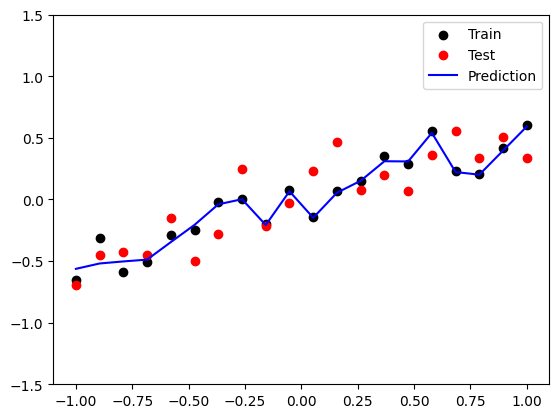

In [ ]:
plt.figure()
plt.scatter(x_train, y_train, c = 'black', label = 'Train')
plt.scatter(x_test, y_test, c = 'red', label = 'Test')
plt.plot(x_test, y_pred, c = 'blue', label = 'Prediction')
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

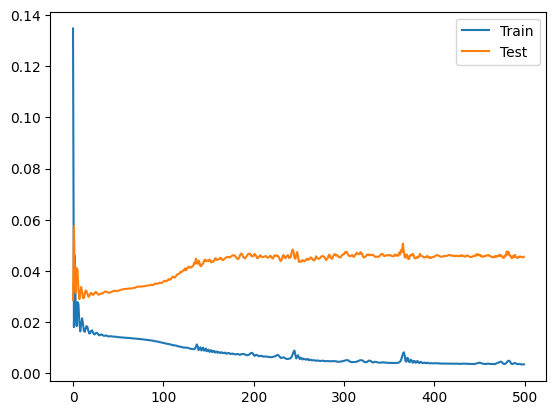

In [ ]:
plt.plot(history.history['loss'], label = 'Train')
plt.plot(history.history['val_loss'], label = 'Test')
plt.legend()
plt.show()

Dropout Model

In [ ]:
model = Sequential()

model.add(Dense(128, input_dim = 1, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation = 'linear'))
adam = Adam(learning_rate = 0.01)
model.compile(loss = 'mse', optimizer = adam, metrics = ['mse'])

history = model.fit(x_train, y_train, epochs =500, validation_data = (x_test, y_test))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1227 - mse: 0.1227 - val_loss: 0.0297 - val_mse: 0.0297
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0240 - mse: 0.0240 - val_loss: 0.0563 - val_mse: 0.0563
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0447 - mse: 0.0447 - val_loss: 0.0405 - val_mse: 0.0405
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0339 - mse: 0.0339 - val_loss: 0.0299 - val_mse: 0.0299
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0228 - mse: 0.0228 - val_loss: 0.0378 - val_mse: 0.0378
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0345 - mse: 0.0345 - val_loss: 0.0443 - val_mse: 0.0443
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0390 - mse: 0.0390 - val_loss: 0.0418 - val_mse: 0.0418
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0281 - mse: 0.0281 - val_loss: 0.0361 - val_mse: 0.0361
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - loss: 0.0224 - mse:

In [ ]:
# evaluate the model
train_mse = model.evaluate(x_train, y_train, verbose = 0)
test_mse = model.evaluate(x_test, y_test, verbose = 0)
print("train : {},\ntest : {}".format(train_mse,test_mse))


train : [0.012477925047278404, 0.012477925047278404],
test : [0.03746066242456436, 0.03746066242456436]


In [ ]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


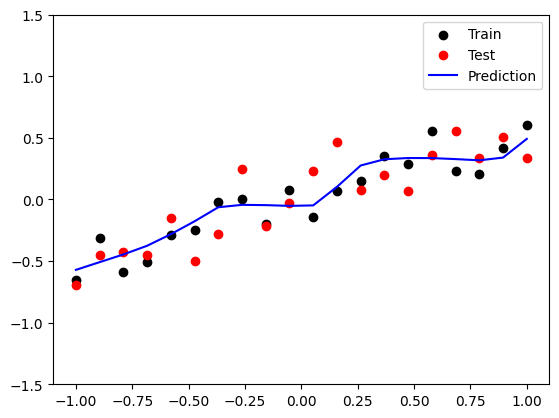

In [ ]:
plt.figure()
plt.scatter(x_train, y_train, c = 'black', label = 'Train')
plt.scatter(x_test, y_test, c = 'red', label = 'Test')
plt.plot(x_test, y_pred, c = 'blue', label = 'Prediction')
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

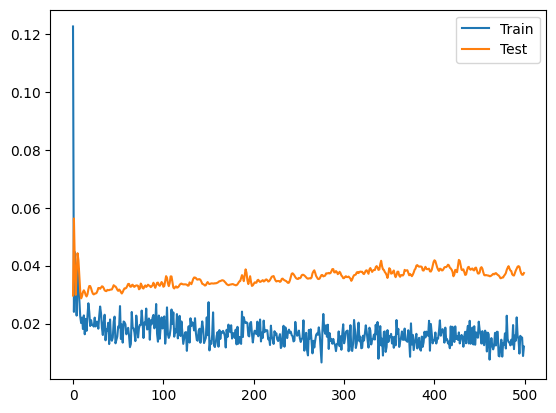

In [ ]:
plt.plot(history.history['loss'], label = 'Train')
plt.plot(history.history['val_loss'], label = 'Test')
plt.legend()
plt.show()

Dropout with 0.5

In [ ]:
model = Sequential()

model.add(Dense(128, input_dim = 1, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation = 'linear'))
adam = Adam(learning_rate = 0.01)
model.compile(loss = 'mse', optimizer = adam, metrics = ['mse'])

history = model.fit(x_train, y_train, epochs =500, validation_data = (x_test, y_test))

Epoch 1/500


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0942 - mse: 0.0942 - val_loss: 0.0365 - val_mse: 0.0365
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0603 - mse: 0.0603 - val_loss: 0.0306 - val_mse: 0.0306
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0203 - mse: 0.0203 - val_loss: 0.0513 - val_mse: 0.0513
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0709 - mse: 0.0709 - val_loss: 0.0425 - val_mse: 0.0425
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0496 - mse: 0.0496 - val_loss: 0.0303 - val_mse: 0.0303
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0729 - mse: 0.0729 - val_loss: 0.0310 - val_mse: 0.0310
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0345 - mse: 0.0345 - val_loss: 0.0384 - val_mse: 0.0384
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0342 - mse: 0.0342 - val_loss: 0.0425 - val_mse: 0.0425
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0399 - mse: 0.0399 - val_

In [ ]:
# evaluate the model
train_mse = model.evaluate(x_train, y_train, verbose = 0)
test_mse = model.evaluate(x_test, y_test, verbose = 0)
print("train : {},\ntest : {}".format(train_mse,test_mse))


train : [0.014270385727286339, 0.014270385727286339],
test : [0.033183254301548004, 0.033183254301548004]


In [ ]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


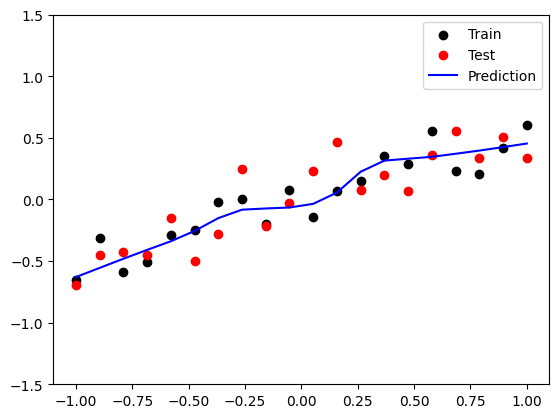

In [ ]:
plt.figure()
plt.scatter(x_train, y_train, c = 'black', label = 'Train')
plt.scatter(x_test, y_test, c = 'red', label = 'Test')
plt.plot(x_test, y_pred, c = 'blue', label = 'Prediction')
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

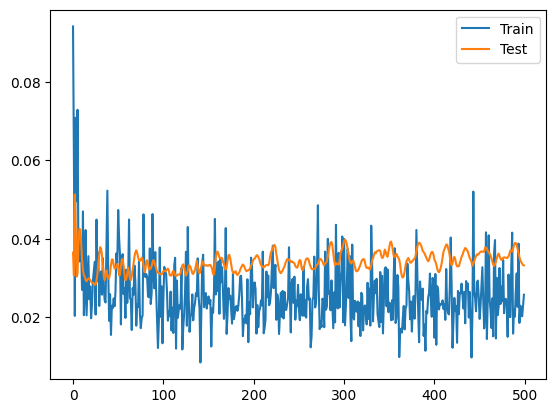

In [ ]:
plt.plot(history.history['loss'], label = 'Train')
plt.plot(history.history['val_loss'], label = 'Test')
plt.legend()
plt.show()